In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [21]:
data=pd.read_csv(r"Z:\Intermship\task#01\retail_store_sales.csv")
data.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [22]:
#print(data['Transaction Date'].dtype)
data_before=data

In [23]:
print(data.isnull().sum())

Transaction ID         0
Customer ID            0
Category               0
Item                 824
Price Per Unit       414
Quantity             410
Total Spent          410
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    2911
dtype: int64


In [24]:
data['Category'].unique()
type1=['Patisserie', 'Milk Products', 'Butchers', 'Beverages', 'Food',
       'Furniture', 'Electric household essentials',
       'Computers and electric accessories']
dict={i:val for val,i in enumerate(type1)}
print(dict)
data['Category']=data['Category'].map(dict)

{'Patisserie': 0, 'Milk Products': 1, 'Butchers': 2, 'Beverages': 3, 'Food': 4, 'Furniture': 5, 'Electric household essentials': 6, 'Computers and electric accessories': 7}


In [25]:
data['Payment Method'].unique()
type2=['Credit Card', 'Digital Wallet', 'Cash']
dict={i:val for val,i in enumerate(type2)}
print(dict)
data['Payment Method']=data['Payment Method'].map(dict)

{'Credit Card': 0, 'Digital Wallet': 1, 'Cash': 2}


In [26]:
data['Discount Applied']=data['Discount Applied'].fillna(data['Discount Applied']).mode()[0]
data['Quantity']=data['Quantity'].fillna(data['Quantity']).mean()
data['Total Spent']=data['Total Spent'].fillna(data['Total Spent']).mean()
data['Price Per Unit']=data['Price Per Unit'].fillna(data['Price Per Unit']).mean()
data['Item']=data['Item'].fillna(data['Item']).mode()[0]
print(data.isnull().sum()) 

Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64


array([ True])

In [28]:
data.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,0,Item_2_BEV,23.43389,5.532857,129.951652,1,Online,2024-04-08,True
1,TXN_3731986,CUST_22,1,Item_2_BEV,23.43389,5.532857,129.951652,1,Online,2023-07-23,True
2,TXN_9303719,CUST_02,2,Item_2_BEV,23.43389,5.532857,129.951652,0,Online,2022-10-05,True
3,TXN_9458126,CUST_06,3,Item_2_BEV,23.43389,5.532857,129.951652,0,Online,2022-05-07,True
4,TXN_4575373,CUST_05,4,Item_2_BEV,23.43389,5.532857,129.951652,1,Online,2022-10-02,True


In [29]:
g=data.groupby('Category')
min_size=g.size().min()
data=g.apply(lambda x: x.sample(min_size)).reset_index(drop=True)


C:\Users\HP\AppData\Local\Temp\ipykernel_5008\160313782.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data=g.apply(lambda x: x.sample(min_size)).reset_index(drop=True)


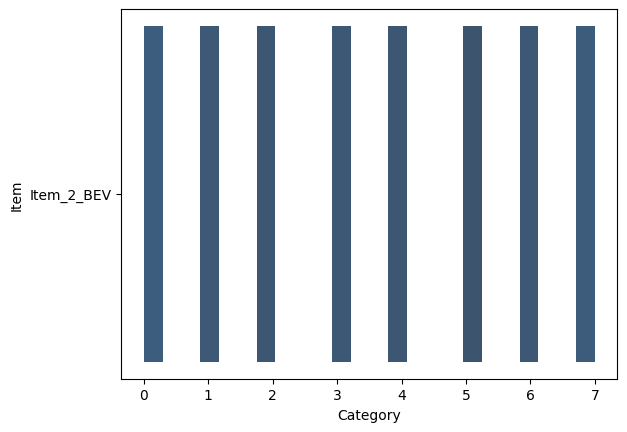

In [30]:
sns.histplot(data=data_before, x='Category',y='Item')
plt.show()

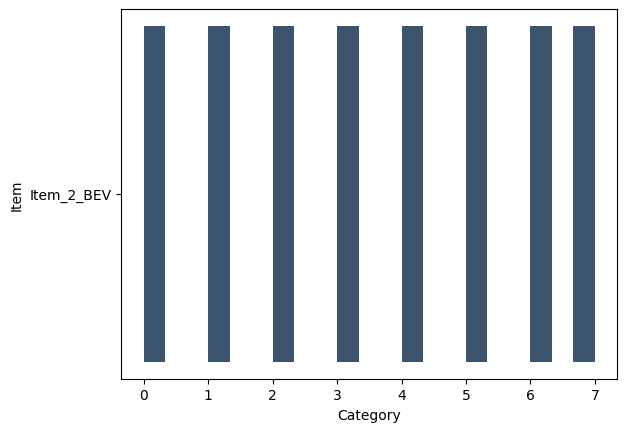

In [31]:
sns.histplot(data=data, x='Category',y='Item')
plt.show()

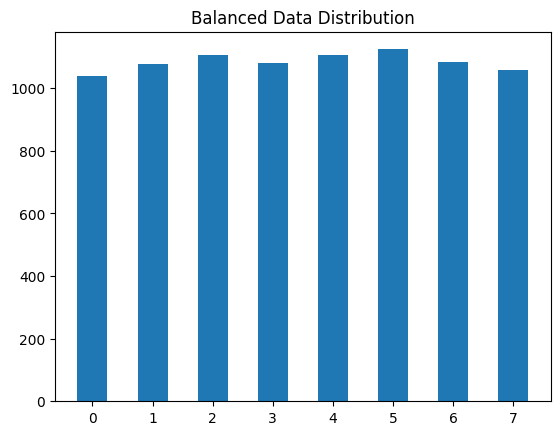

In [32]:
data_plot=data_before['Category'].value_counts()
plt.bar(data_plot.index, data_plot.values, width=0.5)
plt.title("Balanced Data Distribution")
plt.show()

In [ ]:
data_plot=data['Transaction ID'].value_counts()
plt.bar(data_plot.index, data_plot.values, width=0.5)
plt.title("Balanced Data Distribution")
plt.show()